# 🏔️ Ridge Regression From Scratch
**Predicting Discounted Price on Flipkart Dataset**

---

### 🎯 Objective
Predict the `discounted_price` of Flipkart products using a **Ridge Regression** model built entirely from scratch (pure NumPy — no sklearn).

### 📦 From Scratch Components
- Data Cleaning & Preprocessing
- Feature Engineering
- Train-Test Split
- Standard Scaler
- Evaluation Metrics (MAE, MSE, RMSE, R²)
- Ridge Regression (Closed-Form & Gradient Descent)
- Visualizations

## 1️⃣ Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
print('Libraries imported successfully!')

Libraries imported successfully!


## 2️⃣ Load Dataset

In [ ]:
df = pd.read_csv('flipkart_com-ecommerce_sample.csv')
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (20002, 291)


,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,...,price_2026-01-22,price_2026-01-23,price_2026-01-24,price_2026-01-25,price_2026-01-26,price_2026-01-27,price_2026-01-28,price_2026-01-29,price_2026-01-30,price_2026-01-31
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,...,270.0,232.0,244.0,280.0,268.0,348.0,423.0,400.0,381.0,415.0
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,...,19280.0,19910.0,17520.0,16980.0,16540.0,19110.0,21680.0,23180.0,22320.0,22550.0
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,...,329.0,343.0,311.0,381.0,363.0,443.0,462.0,528.0,560.0,493.0


## 3️⃣ Exploratory Data Analysis (EDA)

In [ ]:
# Keep only needed columns
cols = ['product_name','product_category_tree','retail_price','discounted_price',
        'product_rating','overall_rating','brand','is_FK_Advantage_product','description']
df = df[cols].copy()

print('=== Data Types ===')
print(df.dtypes)
print(f'\nShape: {df.shape}')

=== Data Types ===
product_name                   str
product_category_tree          str
retail_price               float64
discounted_price           float64
product_rating                 str
overall_rating                 str
brand                          str
is_FK_Advantage_product     object
description                    str
dtype: object

Shape: (20002, 9)


In [ ]:
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')

=== Missing Values ===
product_name                  2
product_category_tree         2
retail_price                 80
discounted_price             80
product_rating                2
overall_rating                2
brand                      5866
is_FK_Advantage_product       2
description                   4
dtype: int64

Total missing: 6040


In [ ]:
print('=== Numeric Summary ===')
print(df[['retail_price','discounted_price','product_rating','overall_rating']].describe())

=== Numeric Summary ===
        retail_price  discounted_price
count   19922.000000      19922.000000
mean     2979.206104       1973.401767
std      9009.639341       7333.586040
min        35.000000         35.000000
25%       666.000000        350.000000
50%      1040.000000        550.000000
75%      1999.000000        999.000000
max    571230.000000     571230.000000


## 4️⃣ Data Cleaning

In [ ]:
# Step 1: Convert numeric columns
def to_numeric_safe(series):
    return pd.to_numeric(series, errors='coerce')

df['retail_price'] = to_numeric_safe(df['retail_price'])
df['discounted_price'] = to_numeric_safe(df['discounted_price'])
df['product_rating'] = to_numeric_safe(df['product_rating'])
df['overall_rating'] = to_numeric_safe(df['overall_rating'])
print('Step 1: Numeric columns converted')

Step 1: Numeric columns converted


In [ ]:
# Steps 2–3: Drop rows missing critical price columns
before = len(df)
df = df.dropna(subset=['retail_price','discounted_price'])
print(f'Step 2–3: Dropped {before - len(df)} rows with missing price data')

Step 2–3: Dropped 80 rows with missing price data


In [ ]:
# Steps 4–5: Fill missing ratings with MEDIAN
med_pr = df['product_rating'].median()
med_or = df['overall_rating'].median()
n1 = df['product_rating'].isnull().sum()
n2 = df['overall_rating'].isnull().sum()
df['product_rating'] = df['product_rating'].fillna(med_pr)
df['overall_rating'] = df['overall_rating'].fillna(med_or)
print(f'Step 4: Filled {n1} missing product_rating with median={med_pr}')
print(f'Step 5: Filled {n2} missing overall_rating with median={med_or}')

Step 4: Filled 18083 missing product_rating with median=4.0
Step 5: Filled 18083 missing overall_rating with median=4.0


In [ ]:
# Steps 6–8: Fill categorical missing values
df['brand'] = df['brand'].fillna('Unknown')
df['description'] = df['description'].fillna('')
df['product_category_tree'] = df['product_category_tree'].fillna('Unknown')
print('Step 6: Filled missing brand with "Unknown"')
print('Step 7: Filled missing description with empty string')
print('Step 8: Filled missing product_category_tree with "Unknown"')

Step 6: Filled missing brand with "Unknown"
Step 7: Filled missing description with empty string
Step 8: Filled missing product_category_tree with "Unknown"


In [ ]:
# Step 9: Remove outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    before = len(df)
    df = df[(df[column] >= lower) & (df[column] <= upper)]
    print(f'  {column}: Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}, removed {before-len(df)} outliers')
    return df

print('Step 9: Removing outliers (IQR method)')
before = len(df)
df = remove_outliers_iqr(df, 'retail_price')
df = remove_outliers_iqr(df, 'discounted_price')
print(f'  Total outliers removed: {before - len(df)}')

Step 9: Removing outliers (IQR method)
  retail_price: Q1=666, Q3=1999, IQR=1333, removed 2047 outliers
  discounted_price: Q1=340, Q3=849, IQR=509, removed 1156 outliers
  Total outliers removed: 3203


In [ ]:
# Step 10: Remove rows where discounted_price > retail_price
before = len(df)
df = df[df['discounted_price'] <= df['retail_price']]
print(f'Step 10: Removed {before-len(df)} rows where discounted > retail')

Step 10: Removed 0 rows where discounted > retail


In [ ]:
# Final check
print('=== Final Missing Values Check ===')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')
print(f'Final shape: {df.shape}')
print('\n✅ Data cleaning complete!')

=== Final Missing Values Check ===
product_name               0
product_category_tree      0
retail_price               0
discounted_price           0
product_rating             0
overall_rating             0
brand                      0
is_FK_Advantage_product    0
description                0
dtype: int64

Total missing: 0
Final shape: (16719, 9)

✅ Data cleaning complete!


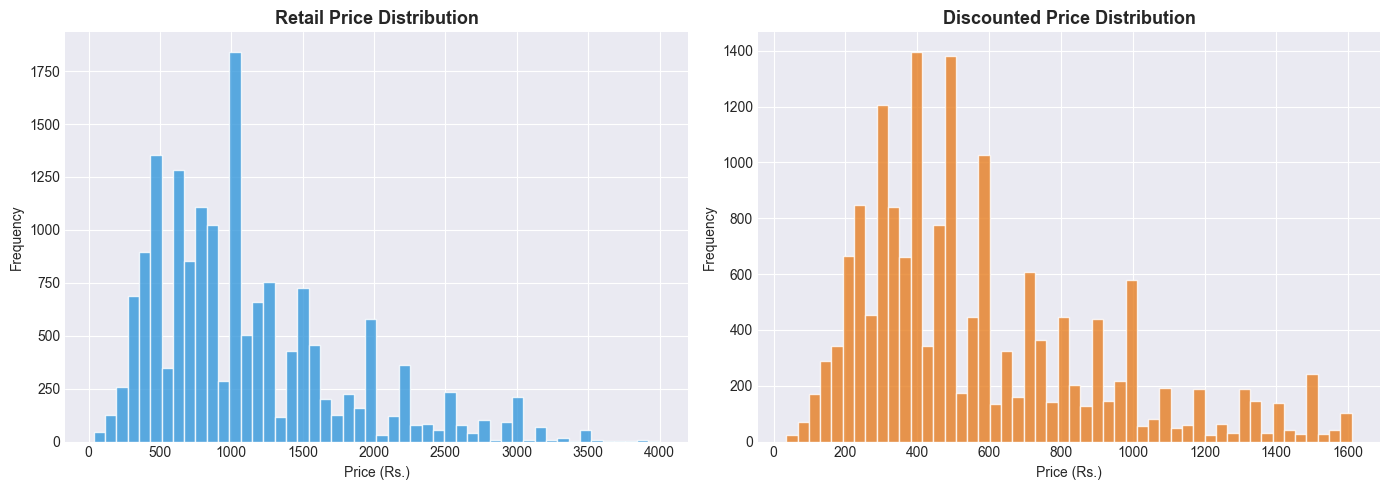

In [ ]:
# Visualize price distributions after cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['retail_price'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Retail Price Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Price (Rs.)')
axes[0].set_ylabel('Frequency')
axes[1].hist(df['discounted_price'], bins=50, color='#e67e22', edgecolor='white', alpha=0.8)
axes[1].set_title('Discounted Price Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Price (Rs.)')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## 5️⃣ Feature Engineering

In [ ]:
df['main_category'] = df['product_category_tree'].apply(
    lambda x: str(x).split('>>')[0].strip().strip('["') if pd.notna(x) else 'Unknown'
)
df['name_length'] = df['product_name'].apply(lambda x: len(str(x)))
df['desc_length'] = df['description'].apply(lambda x: len(str(x)))
df['discount_pct'] = ((df['retail_price'] - df['discounted_price']) / df['retail_price']) * 100
df['discount_pct'] = df['discount_pct'].clip(0, 100)
df['fk_advantage'] = df['is_FK_Advantage_product'].astype(int)
print('Features created: name_length, desc_length, discount_pct, fk_advantage, main_category')

Features created: name_length, desc_length, discount_pct, fk_advantage, main_category


In [ ]:
# Label Encode (FROM SCRATCH)
def label_encode(series):
    unique_vals = sorted(series.dropna().unique())
    mapping = {val: idx for idx, val in enumerate(unique_vals)}
    return series.map(mapping), mapping

df['brand_encoded'], brand_mapping = label_encode(df['brand'])
df['category_encoded'], category_mapping = label_encode(df['main_category'])
print(f'Brand encoded: {len(brand_mapping)} labels')
print(f'Category encoded: {len(category_mapping)} labels')

Brand encoded: 3001 labels
Category encoded: 226 labels


In [ ]:
feature_cols = ['retail_price','product_rating','overall_rating','brand_encoded',
                'category_encoded','fk_advantage','name_length','desc_length','discount_pct']
target_col = 'discounted_price'
X = df[feature_cols].values.astype(np.float64)
y = df[target_col].values.astype(np.float64)
valid = ~(np.isnan(X).any(axis=1) | np.isnan(y))
X, y = X[valid], y[valid]
print(f'Feature matrix: {X.shape}, Target: {y.shape}')

Feature matrix: (16719, 9), Target: (16719,)


## 6️⃣ Train-Test Split (From Scratch)

In [ ]:
def train_test_split_scratch(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    n = len(X); n_test = int(n * test_size)
    idx = np.arange(n); np.random.shuffle(idx)
    return X[idx[n_test:]], X[idx[:n_test]], y[idx[n_test:]], y[idx[:n_test]]

X_train, X_test, y_train, y_test = train_test_split_scratch(X, y)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 13376, Test: 3343


## 7️⃣ Standard Scaler (From Scratch)

In [ ]:
class StandardScalerScratch:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        self.std_[self.std_ == 0] = 1  # avoid division by zero
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

scaler = StandardScalerScratch()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('StandardScaler applied: mean=0, std=1 per feature')

StandardScaler applied: mean=0, std=1 per feature


## 8️⃣ Evaluation Metrics (From Scratch)

In [ ]:
def mean_absolute_error(y_true, y_pred): return np.mean(np.abs(y_true - y_pred))
def mean_squared_error(y_true, y_pred): return np.mean((y_true - y_pred)**2)
def root_mean_squared_error(y_true, y_pred): return np.sqrt(mean_squared_error(y_true, y_pred))
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)
print('Metrics defined: MAE, MSE, RMSE, R2')

Metrics defined: MAE, MSE, RMSE, R2


## 9️⃣ Ridge Regression (From Scratch)

In [ ]:
class RidgeRegressionScratch:
    """
    Ridge Regression from scratch using NumPy.
    Supports two solvers:
      - 'closed_form': Analytical solution  w = (X'X + αI)^{-1} X'y
      - 'gradient_descent': Iterative gradient-based optimization
    """

    def __init__(self, alpha=1.0, solver='closed_form',
                 learning_rate=0.01, n_iterations=1000):
        self.alpha = alpha
        self.solver = solver
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _add_bias(self, X):
        return np.column_stack([np.ones(X.shape[0]), X])

    def _fit_closed_form(self, X, y):
        Xb = self._add_bias(X)
        n_features = Xb.shape[1]
        # Regularization matrix: don't regularize bias term
        reg_matrix = self.alpha * np.eye(n_features)
        reg_matrix[0, 0] = 0
        w = np.linalg.solve(Xb.T @ Xb + reg_matrix, Xb.T @ y)
        self.bias = w[0]
        self.weights = w[1:]

    def _fit_gradient_descent(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []
        for i in range(self.n_iterations):
            y_pred = X @ self.weights + self.bias
            error = y_pred - y
            # Loss = MSE + alpha * ||w||^2
            loss = np.mean(error**2) + self.alpha * np.sum(self.weights**2)
            self.loss_history.append(loss)
            dw = (2 / n_samples) * (X.T @ error) + 2 * self.alpha * self.weights
            db = (2 / n_samples) * np.sum(error)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def fit(self, X, y):
        if self.solver == 'closed_form':
            self._fit_closed_form(X, y)
        else:
            self._fit_gradient_descent(X, y)
        return self

    def predict(self, X):
        return X @ self.weights + self.bias

print('RidgeRegressionScratch defined!')

RidgeRegressionScratch defined!


## 🔟 Train Ridge Regression — Closed-Form

In [ ]:
import time

ridge_cf = RidgeRegressionScratch(alpha=1.0, solver='closed_form')
t0 = time.time()
ridge_cf.fit(X_train_scaled, y_train)
cf_time = time.time() - t0

y_pred_cf = ridge_cf.predict(X_test_scaled)
cf_mae  = mean_absolute_error(y_test, y_pred_cf)
cf_mse  = mean_squared_error(y_test, y_pred_cf)
cf_rmse = root_mean_squared_error(y_test, y_pred_cf)
cf_r2   = r2_score(y_test, y_pred_cf)

print(f'Time: {cf_time:.4f}s | MAE: Rs.{cf_mae:,.2f} | RMSE: Rs.{cf_rmse:,.2f} | R2: {cf_r2:.4f}')

Time: 0.0034s | MAE: Rs.94.17 | RMSE: Rs.132.01 | R2: 0.8434


## 1️⃣1️⃣ Train Ridge Regression — Gradient Descent

In [ ]:
ridge_gd = RidgeRegressionScratch(alpha=1.0, solver='gradient_descent',
                                   learning_rate=0.01, n_iterations=2000)
t0 = time.time()
ridge_gd.fit(X_train_scaled, y_train)
gd_time = time.time() - t0

y_pred_gd = ridge_gd.predict(X_test_scaled)
gd_mae  = mean_absolute_error(y_test, y_pred_gd)
gd_mse  = mean_squared_error(y_test, y_pred_gd)
gd_rmse = root_mean_squared_error(y_test, y_pred_gd)
gd_r2   = r2_score(y_test, y_pred_gd)

print(f'Time: {gd_time:.2f}s | MAE: Rs.{gd_mae:,.2f} | RMSE: Rs.{gd_rmse:,.2f} | R2: {gd_r2:.4f}')
print('\n✅ Ridge Regression (both solvers) trained!')

Time: 0.45s | MAE: Rs.176.64 | RMSE: Rs.226.26 | R2: 0.5401

✅ Ridge Regression (both solvers) trained!


## 1️⃣2️⃣ Evaluate & Compare Solvers

In [ ]:
print('='*60)
print(f'{"Metric":<18} {"Closed-Form":>18} {"Gradient Descent":>18}')
print(f'{"─"*18} {"─"*18} {"─"*18}')
print(f'{"MAE (Rs.)":<18} {cf_mae:>18,.2f} {gd_mae:>18,.2f}')
print(f'{"MSE":<18} {cf_mse:>18,.2f} {gd_mse:>18,.2f}')
print(f'{"RMSE (Rs.)":<18} {cf_rmse:>18,.2f} {gd_rmse:>18,.2f}')
print(f'{"R2 Score":<18} {cf_r2:>18.4f} {gd_r2:>18.4f}')
print('='*60)

Metric                    Closed-Form   Gradient Descent
────────────────── ────────────────── ──────────────────
MAE (Rs.)                       94.17             176.64
MSE                         17,427.16          51,191.63
RMSE (Rs.)                     132.01             226.26
R2 Score                       0.8434             0.5401


## 1️⃣3️⃣ Visualization: Model Comparison Bar Chart

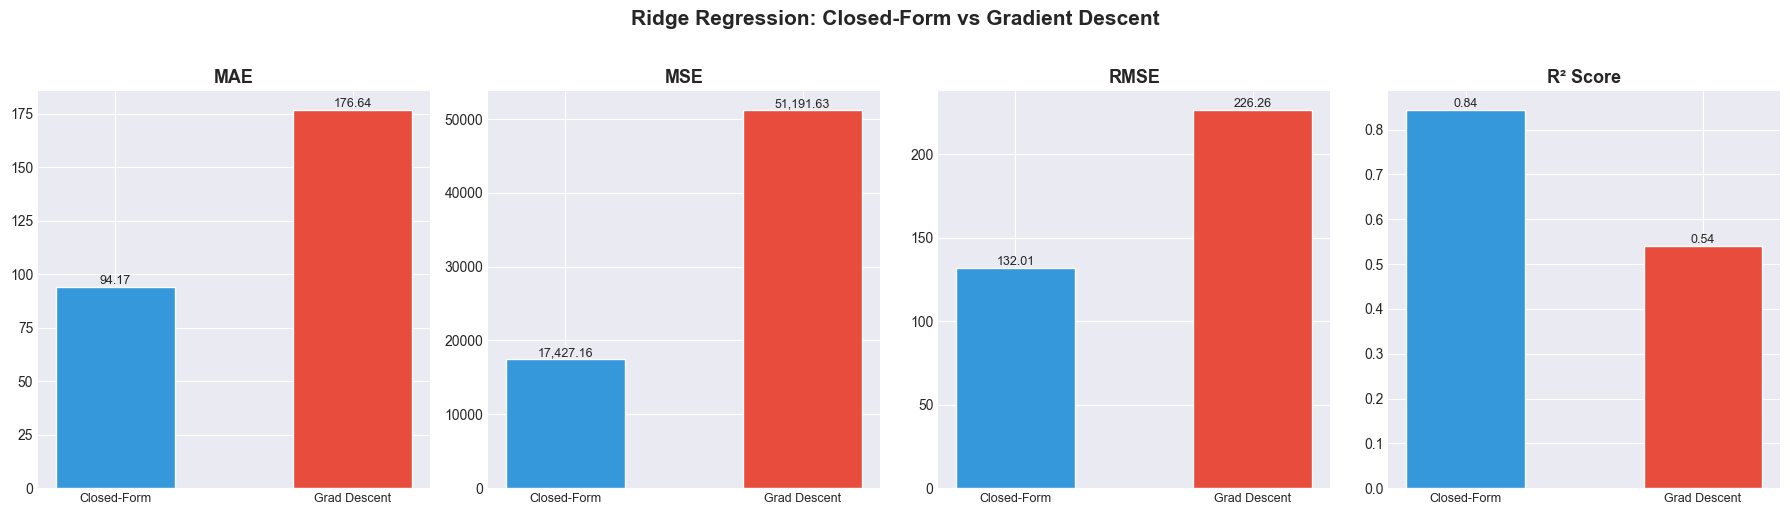

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['MAE', 'MSE', 'RMSE', 'R² Score']
cf_vals = [cf_mae, cf_mse, cf_rmse, cf_r2]
gd_vals = [gd_mae, gd_mse, gd_rmse, gd_r2]
color_cf = '#3498db'
color_gd = '#e74c3c'

for i, (ax, m) in enumerate(zip(axes, metrics)):
    x = np.arange(2)
    bars = ax.bar(x, [cf_vals[i], gd_vals[i]], color=[color_cf, color_gd], width=0.5, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(['Closed-Form', 'Grad Descent'], fontsize=9)
    ax.set_title(m, fontsize=13, fontweight='bold')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h, f'{h:,.2f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Ridge Regression: Closed-Form vs Gradient Descent', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 1️⃣4️⃣ Visualization: Actual vs Predicted (Scatter Plot)

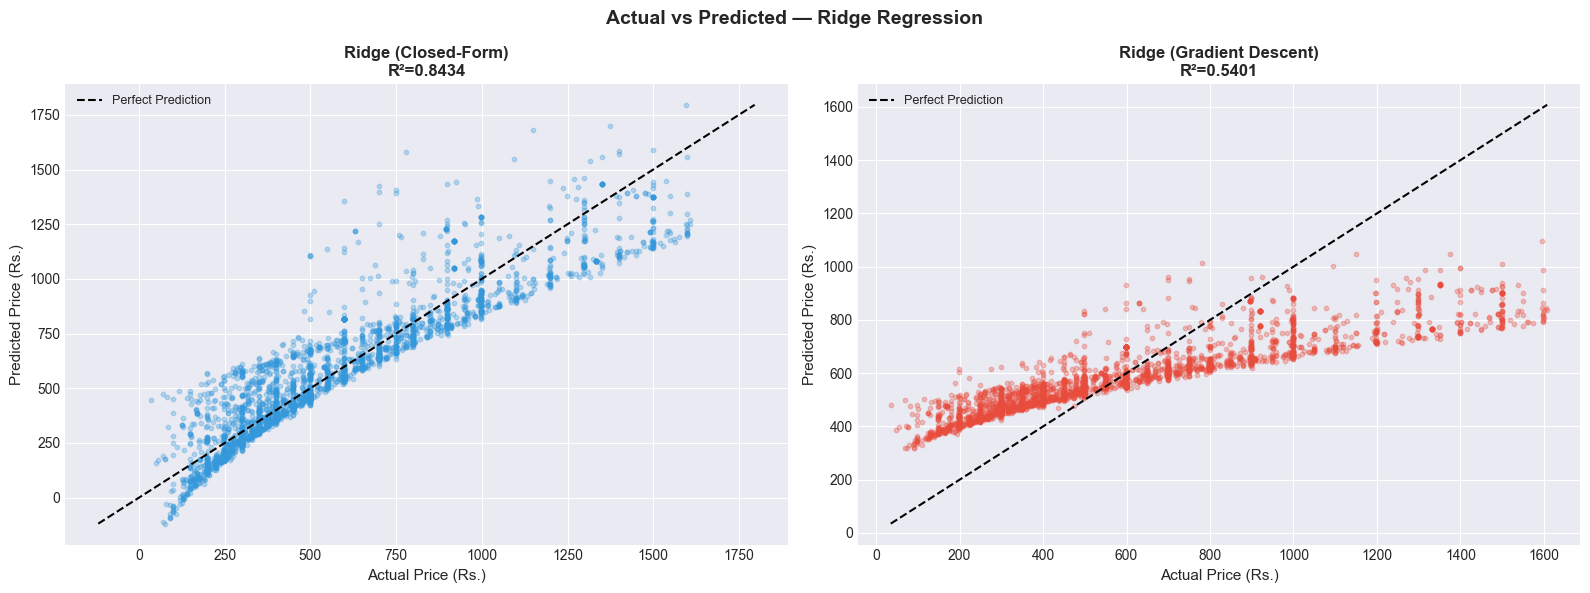

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, label, color in zip(
    axes,
    [y_pred_cf, y_pred_gd],
    ['Closed-Form', 'Gradient Descent'],
    ['#3498db', '#e74c3c']
):
    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color=color)
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect Prediction')
    ax.set_xlabel('Actual Price (Rs.)', fontsize=11)
    ax.set_ylabel('Predicted Price (Rs.)', fontsize=11)
    ax.set_title(f'Ridge ({label})\nR²={r2_score(y_test, y_pred):.4f}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted — Ridge Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1️⃣5️⃣ Visualization: Loss Curve (Gradient Descent)

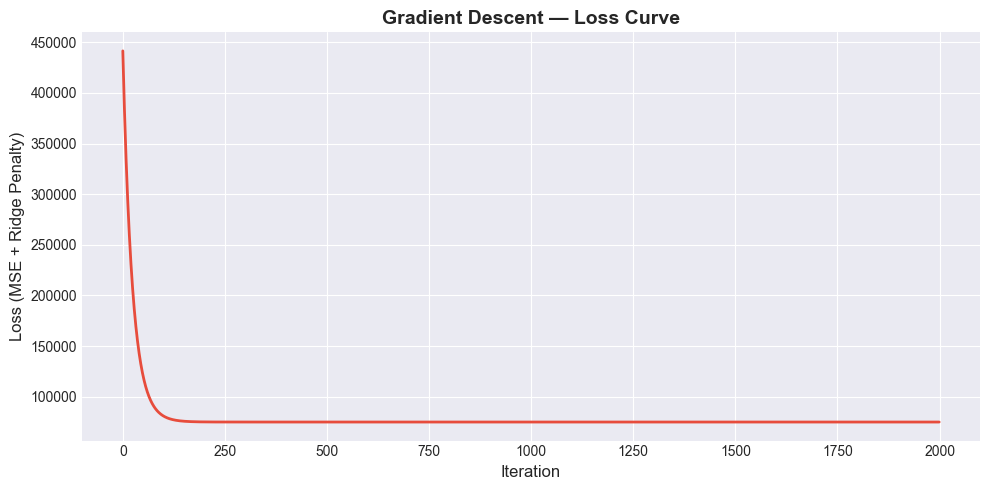

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(ridge_gd.loss_history, color='#e74c3c', lw=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss (MSE + Ridge Penalty)', fontsize=12)
plt.title('Gradient Descent — Loss Curve', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1️⃣6️⃣ Visualization: Effect of Alpha (Regularization Strength)

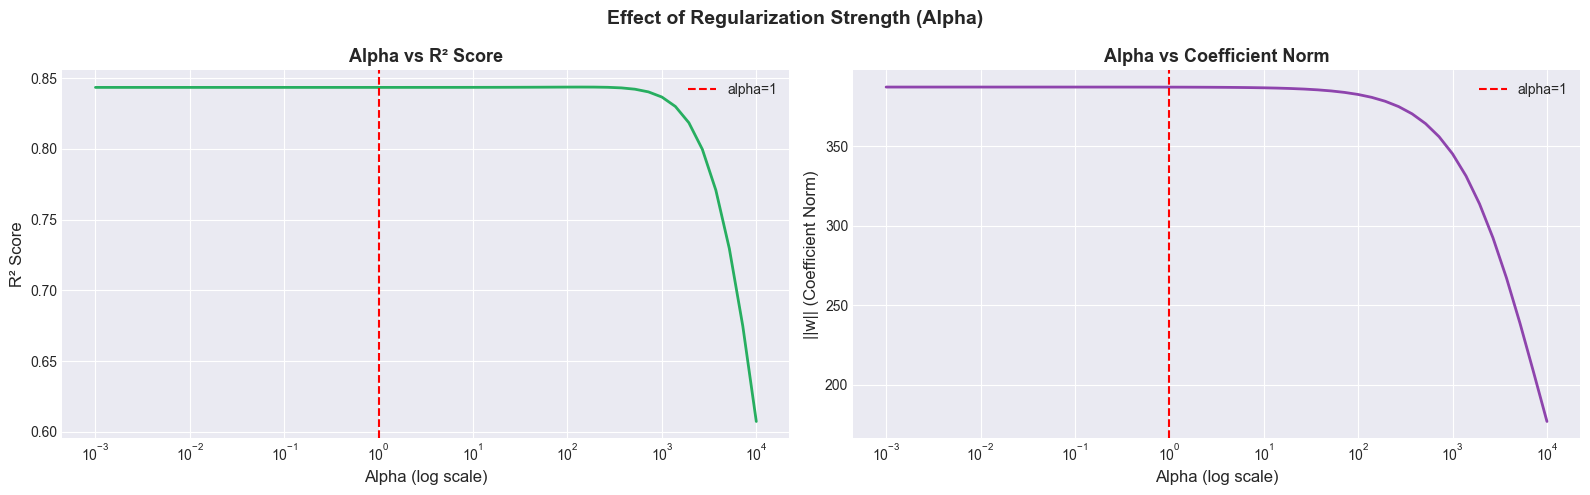

In [ ]:
alphas = np.logspace(-3, 4, 50)  # 0.001 to 10000
r2_scores = []
coef_norms = []

for a in alphas:
    m = RidgeRegressionScratch(alpha=a, solver='closed_form')
    m.fit(X_train_scaled, y_train)
    r2_scores.append(r2_score(y_test, m.predict(X_test_scaled)))
    coef_norms.append(np.linalg.norm(m.weights))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].semilogx(alphas, r2_scores, color='#27ae60', lw=2)
axes[0].set_xlabel('Alpha (log scale)', fontsize=12)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Alpha vs R² Score', fontsize=13, fontweight='bold')
axes[0].axvline(1.0, color='red', linestyle='--', label='alpha=1')
axes[0].legend()

axes[1].semilogx(alphas, coef_norms, color='#8e44ad', lw=2)
axes[1].set_xlabel('Alpha (log scale)', fontsize=12)
axes[1].set_ylabel('||w|| (Coefficient Norm)', fontsize=12)
axes[1].set_title('Alpha vs Coefficient Norm', fontsize=13, fontweight='bold')
axes[1].axvline(1.0, color='red', linestyle='--', label='alpha=1')
axes[1].legend()

plt.suptitle('Effect of Regularization Strength (Alpha)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1️⃣7️⃣ Visualization: Feature Weights

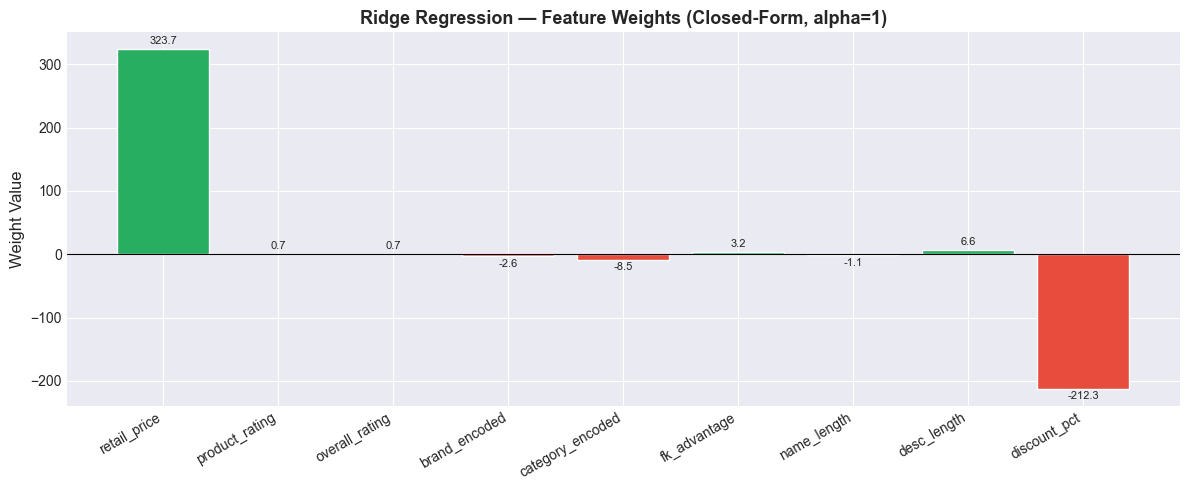

In [ ]:
weights = ridge_cf.weights
colors = ['#27ae60' if w >= 0 else '#e74c3c' for w in weights]

plt.figure(figsize=(12, 5))
bars = plt.bar(feature_cols, weights, color=colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
for bar, w in zip(bars, weights):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (5 if w >= 0 else -20),
             f'{w:.1f}', ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylabel('Weight Value', fontsize=12)
plt.title('Ridge Regression — Feature Weights (Closed-Form, alpha=1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 1️⃣8️⃣ Residual Analysis

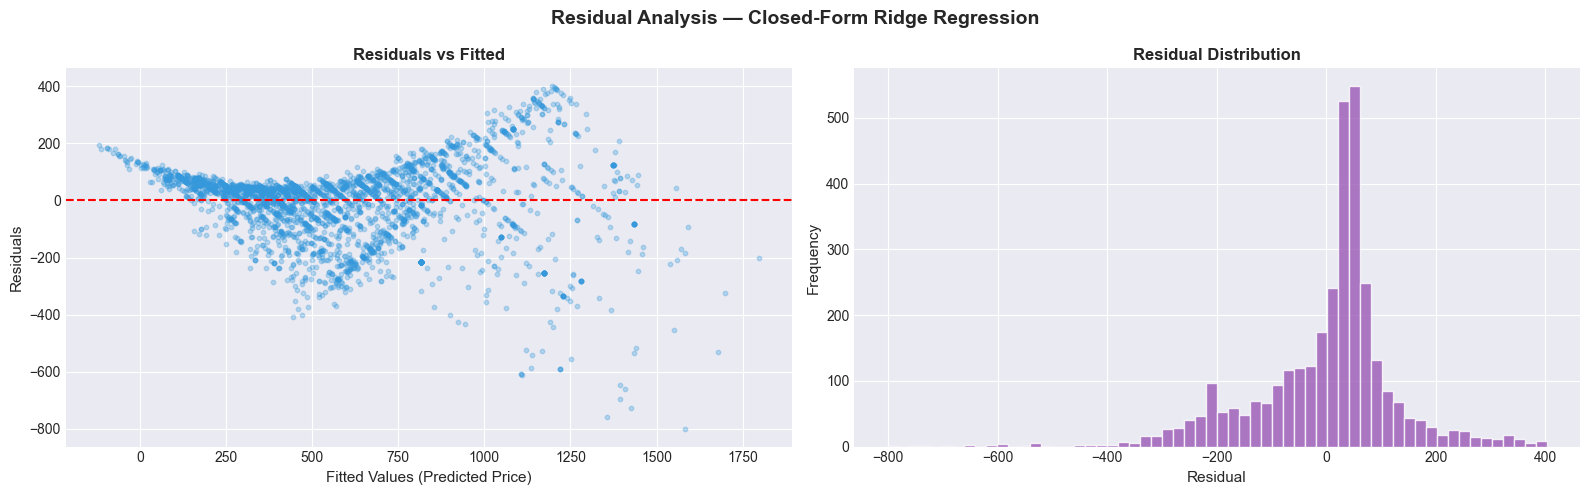

In [ ]:
residuals = y_test - y_pred_cf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Residual vs Fitted
axes[0].scatter(y_pred_cf, residuals, alpha=0.3, s=10, color='#3498db')
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Fitted Values (Predicted Price)', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].set_title('Residuals vs Fitted', fontsize=12, fontweight='bold')

# Residual histogram
axes[1].hist(residuals, bins=60, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Residual', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Residual Distribution', fontsize=12, fontweight='bold')

plt.suptitle('Residual Analysis — Closed-Form Ridge Regression', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1️⃣9️⃣ Summary

In [ ]:
print('=' * 60)
print('        RIDGE REGRESSION — FINAL SUMMARY')
print('=' * 60)
print(f'  Dataset size (after cleaning) : {X.shape[0]:,} samples')
print(f'  Features                      : {X.shape[1]}')
print(f'  Regularization alpha          : 1.0')
print()
print(f'  ── Closed-Form ──')
print(f'     Training time : {cf_time:.4f} s')
print(f'     MAE           : Rs. {cf_mae:,.2f}')
print(f'     RMSE          : Rs. {cf_rmse:,.2f}')
print(f'     R²            : {cf_r2:.4f}')
print()
print(f'  ── Gradient Descent ──')
print(f'     Training time : {gd_time:.2f} s')
print(f'     MAE           : Rs. {gd_mae:,.2f}')
print(f'     RMSE          : Rs. {gd_rmse:,.2f}')
print(f'     R²            : {gd_r2:.4f}')
print('=' * 60)
print('✅ Notebook complete!')

        RIDGE REGRESSION — FINAL SUMMARY
  Dataset size (after cleaning) : 16,719 samples
  Features                      : 9
  Regularization alpha          : 1.0

  ── Closed-Form ──
     Training time : 0.0034 s
     MAE           : Rs. 94.17
     RMSE          : Rs. 132.01
     R²            : 0.8434

  ── Gradient Descent ──
     Training time : 0.45 s
     MAE           : Rs. 176.64
     RMSE          : Rs. 226.26
     R²            : 0.5401
✅ Notebook complete!
